In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path
import geopandas as gpd
import csv

REPO_ROOT = Path("/home/sou/git/skill-migration")
DATA = REPO_ROOT / "sou" / "data"
PROC = DATA / "processed"
RAW = DATA / "raw" / "kokkai"
FIG_DIR = REPO_ROOT / "sou" / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.font_manager as fm
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ["Noto Sans CJK JP", "IPAexGothic", "IPAGothic"]:
    if _f in _avail:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print(f"Data: {DATA}")
print(f"Font: {plt.rcParams['font.family']}")


Data: /home/sou/git/skill-migration/sou/data
Font: ['Noto Sans CJK JP']


In [2]:
# Load: stances + metadata + district
with open(RAW / "metadata.json", encoding="utf-8") as f:
    meta = json.load(f)["speeches"]
with open(PROC / "kokkai_stances_clean.json", encoding="utf-8") as f:
    stances = json.load(f)["speech_stances"]
speakers = list(csv.DictReader(open(PROC / "speaker_district_switcher.csv", encoding="utf-8")))

# Normalize district strings. Keep 全国 as a valid bucket for national analysis.
VALID_PREF = {"北海道","青森県","岩手県","宮城県","秋田県","山形県","福島県","茨城県",
             "栃木県","群馬県","埼玉県","千葉県","東京都","神奈川県","新潟県","富山県",
             "石川県","福井県","山梨県","長野県","岐阜県","静岡県","愛知県","三重県",
             "滋賀県","京都府","大阪府","兵庫県","奈良県","和歌山県","鳥取県","島根県",
             "岡山県","広島県","山口県","徳島県","香川県","愛媛県","高知県","福岡県",
             "佐賀県","長崎県","熊本県","大分県","宮崎県","鹿児島県","沖縄県","全国"}
PREF_STEMS = sorted(
    [(p[:-1] if p.endswith(("県","府")) else (p[:-2] if p.endswith("都") else p), p)
     for p in VALID_PREF if p != "全国"],
    key=lambda kv: -len(kv[0]),
)

def normalize_pref(raw):
    if not raw or raw.startswith("|") or raw.startswith("{{"):
        return None
    if raw in VALID_PREF:
        return raw
    if raw.endswith("区"):
        for stem, canonical in PREF_STEMS:
            if raw.startswith(stem):
                return canonical
    for sep in ["・","、",","]:
        if sep in raw:
            first = raw.split(sep, 1)[0].strip()
            if first in VALID_PREF:
                return first
    return None

sp_pref = {s["speaker"]: normalize_pref(s.get("district_prefecture")) for s in speakers}
sp_pref = {k: v for k, v in sp_pref.items() if v}  # keep 全国 as a valid bucket

rows = []
for sid, st in stances.items():
    m = meta.get(sid, {})
    sp = m.get("speaker", "")
    pref = sp_pref.get(sp)
    rows.append({"sid": sid, "speaker": sp, "prefecture": pref, "label": st["label"]})
df = pd.DataFrame(rows)
print(f"all speeches (with normalized prefecture, incl. 全国): {len(df):,}")
print(f"  prefectures incl. 全国: {df['prefecture'].nunique()}")
print(f"  全国 (PR block) speeches: {(df['prefecture']=='全国').sum():,}")
print(f"  anti (with prefecture incl. 全国): {((df['label']=='anti') & df['prefecture'].notna()).sum():,}")

# Two views:
#   df_anti  = ALL anti speeches with a valid prefecture bucket (incl. 全国) — for NATIONAL analysis
#   df_anti_pref = only proper prefectures (no 全国) — for PREFECTURE analysis
df_anti = df[(df["label"] == "anti") & df["prefecture"].notna()].copy()
df_anti_pref = df_anti[df_anti["prefecture"] != "全国"].copy()
print(f"\nNational anti (incl. 全国): {len(df_anti):,} speeches, {df_anti['speaker'].nunique()} speakers")
print(f"Prefecture-level anti (excl. 全国): {len(df_anti_pref):,} speeches, {df_anti_pref['speaker'].nunique()} speakers, {df_anti_pref['prefecture'].nunique()} prefectures")


all speeches (with normalized prefecture, incl. 全国): 10,736
  prefectures incl. 全国: 46
  全国 (PR block) speeches: 2,865
  anti (with prefecture incl. 全国): 1,894

National anti (incl. 全国): 1,894 speeches, 333 speakers
Prefecture-level anti (excl. 全国): 898 speeches, 183 speakers, 43 prefectures


Top 15 anti-immigration speakers (national):
speaker  anti_count  share_pct  cumulative_pct
   仁比聡平         117        6.2             6.2
   藤野保史          54        2.9             9.1
  福島みずほ          48        2.5            11.6
   有田芳生          44        2.3            13.9
   川合孝典          43        2.3            16.2
   山口和之          40        2.1            18.3
   石橋通宏          35        1.8            20.1
   逢坂誠二          32        1.7            21.8
   糸数慶子          31        1.6            23.4
    櫻井充          30        1.6            25.0
     階猛          29        1.5            26.5
   山下貴司          27        1.4            27.9
   本村伸子          25        1.3            29.2
   小川敏夫          25        1.3            30.5
   山井和則          25        1.3            31.8


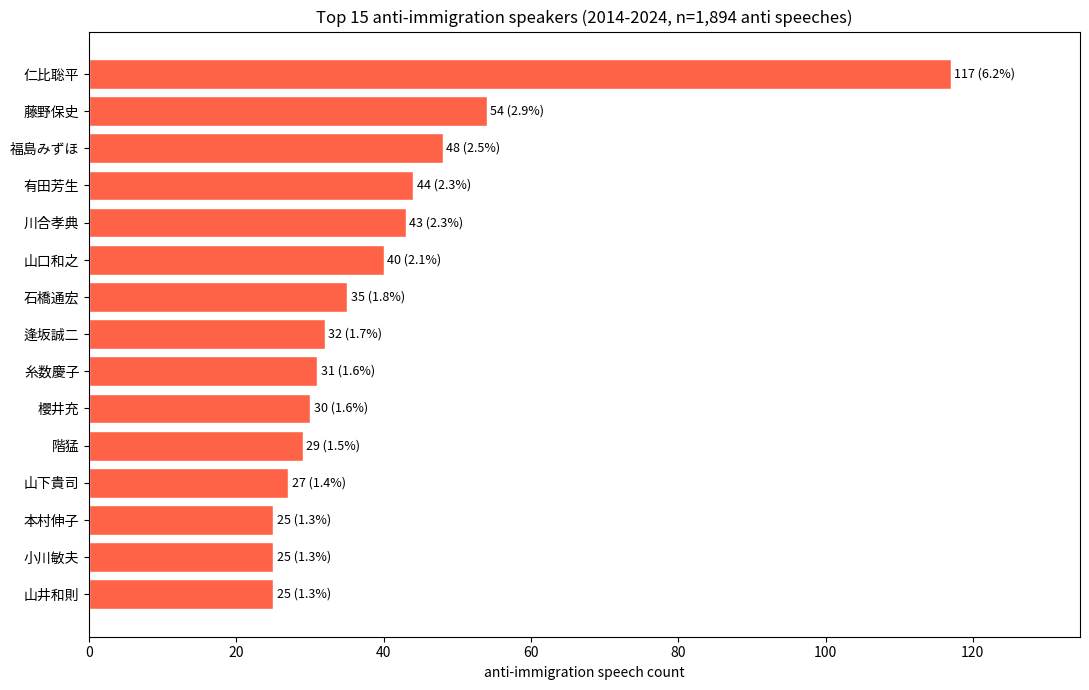

In [3]:
# National: top-15 anti speakers (raw count + share of all anti)
top15 = (df_anti.groupby("speaker").size()
         .sort_values(ascending=False).head(15).reset_index(name="anti_count"))
top15["share_pct"] = (top15["anti_count"] / len(df_anti) * 100).round(1)
top15["cumulative_pct"] = top15["share_pct"].cumsum().round(1)
print("Top 15 anti-immigration speakers (national):")
print(top15.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(range(len(top15)), top15["anti_count"], color="tomato", edgecolor="white")
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["speaker"])
ax.invert_yaxis()
for i, (cnt, sh) in enumerate(zip(top15["anti_count"], top15["share_pct"])):
    ax.text(cnt + 0.5, i, f"{cnt} ({sh}%)", va="center", fontsize=9)
ax.set_xlabel("anti-immigration speech count")
ax.set_title(f"Top 15 anti-immigration speakers (2014-2024, n={len(df_anti):,} anti speeches)")
ax.set_xlim(0, top15["anti_count"].max() * 1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_top15_anti_speakers.png", bbox_inches="tight")
plt.show()


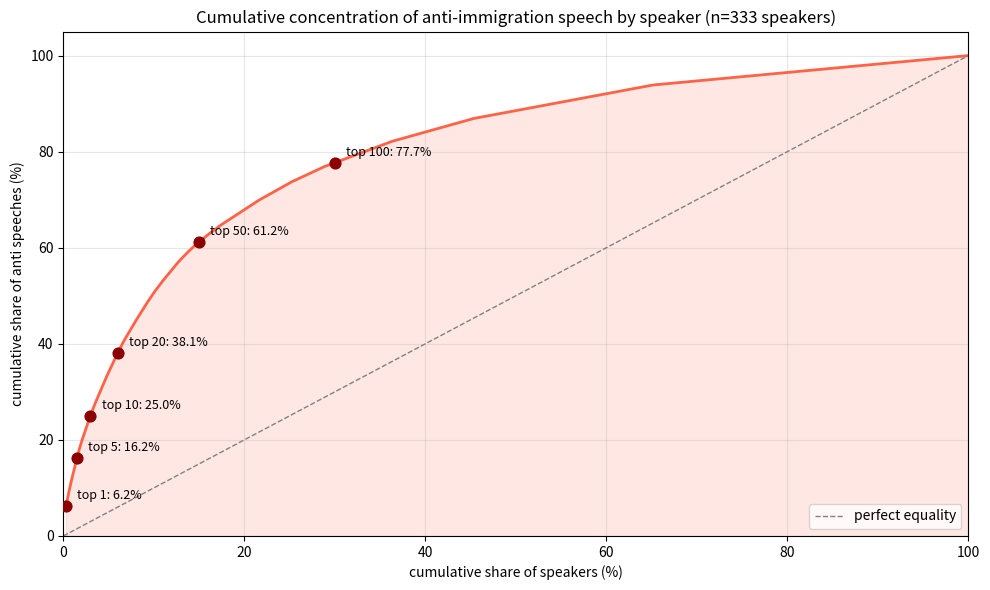

Concentration summary (national):
  top    1 of 333 speakers = 6.2% of all anti speeches
  top    5 of 333 speakers = 16.2% of all anti speeches
  top   10 of 333 speakers = 25.0% of all anti speeches
  top   20 of 333 speakers = 38.1% of all anti speeches
  top   50 of 333 speakers = 61.2% of all anti speeches
  top  100 of 333 speakers = 77.7% of all anti speeches
  top  333 of 333 speakers = 100.0% of all anti speeches


In [4]:
# National: cumulative concentration (top N speakers' share of all anti)
counts = df_anti.groupby("speaker").size().sort_values(ascending=False)
total = counts.sum()
cum_pct = (counts.cumsum() / total * 100)
rank = np.arange(1, len(counts) + 1)
rank_pct = rank / len(counts) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rank_pct, cum_pct, color="tomato", linewidth=2)
ax.fill_between(rank_pct, cum_pct, alpha=0.15, color="tomato")
ax.plot([0, 100], [0, 100], color="grey", linestyle="--", linewidth=1, label="perfect equality")
ax.set_xlabel("cumulative share of speakers (%)")
ax.set_ylabel("cumulative share of anti speeches (%)")
ax.set_title(f"Cumulative concentration of anti-immigration speech by speaker (n={len(counts)} speakers)")

# annotate key thresholds
for n in [1, 5, 10, 20, 50, 100]:
    if n <= len(counts):
        share = cum_pct.iloc[n - 1]
        ax.scatter([n / len(counts) * 100], [share], s=60, zorder=5, color="darkred")
        ax.annotate(f"top {n}: {share:.1f}%", (n / len(counts) * 100, share),
                    xytext=(8, 5), textcoords="offset points", fontsize=9)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_cumulative_concentration.png", bbox_inches="tight")
plt.show()

print("Concentration summary (national):")
for n in [1, 5, 10, 20, 50, 100, len(counts)]:
    if n <= len(counts):
        print(f"  top {n:>4d} of {len(counts)} speakers = {cum_pct.iloc[n-1]:.1f}% of all anti speeches")


In [5]:
# 3 anti-immigration speaker examples (text excerpts)
# Pick one speech each from the top 3 most-prolific anti speakers, with diverse party/region angles
def first_anti_speech(speaker_name, df):
    """Find one anti speech by this speaker with the longest text (most substantial)."""
    sp_df = df[(df['speaker'] == speaker_name) & (df['label'] == 'anti')].copy()
    if len(sp_df) == 0:
        return None
    # Join with metadata to get text
    sp_df['text'] = sp_df['sid'].map(lambda sid: (meta.get(sid) or {}).get('speech', ''))
    sp_df['text_len'] = sp_df['text'].str.len()
    sp_df = sp_df.sort_values('text_len', ascending=False)
    return sp_df.iloc[0]

examples = [
    ("仁比聡平", "National #1 anti voice — JCP, 参議院, 比例代表 (117 anti speeches, 6.2% of all)"),
    ("福島みずほ", "Cross-party angle — 立憲民主・社民, 参議院, 比例代表 (48 anti speeches, 2.5%)"),
    ("逢坂誠二", "District-based politician — 立憲民主, 衆議院, 北海道8区 (32 anti speeches, 1.7%)"),
]

for name, desc in examples:
    row = first_anti_speech(name, df_anti)
    if row is None:
        print(f"[SKIP] {name}: no anti speech found")
        continue
    m = meta.get(row['sid']) or {}
    text = m.get('speech', '').replace('\u3000', ' ').replace('\r', '').strip()
    # Trim to first 400 chars for readability
    excerpt = text[:400] + ('...' if len(text) > 400 else '')
    print("=" * 70)
    print(f"[{name}] {desc}")
    print(f"  date: {m.get('date', '')}, house: {m.get('nameOfHouse', '')}, party: {m.get('speakerGroup', '')}")
    print(f"  speechID: {m.get('speechID', '')}")
    print(f"  text ({len(text)} chars):")
    print(f"    {excerpt}")
    print()

[仁比聡平] National #1 anti voice — JCP, 参議院, 比例代表 (117 anti speeches, 6.2% of all)
  date: 2018-11-28, house: 参議院, party: 日本共産党
  speechID: 119715254X00520181128_067
  text (3354 chars):
    ○仁比聡平君 私は、日本共産党を代表して、出入国管理法及び法務省設置法改定案について、総理並びに関係大臣に質問いたします。
 本法案に、世論調査では六割から八割の国民が今国会の成立にこだわるべきではないと答え、その声は急速に広がっています。またもや民意を踏みにじり、昨日、衆議院でまともな審議もないまま強行採決で押し通し、今日、こんな夕方からの異常な本会議を強行した政府・与党は恥を知るべきであります。
 総理、これほど乱暴に事を推し進めるのはなぜですか。二〇一六年、日本経団連が、労働力不足がボトルネックとして一定の技能を有する外国人材の活用を求めた提言など、財界の要請を何より優先するからではありませんか。
 政府は、九〇年代以来、低賃金で従順に働く労働力として外国人労働者の受入れ策をなし崩しに推し進めてきました。リーマン・ショックでは多くの日系人が派遣切りで母国に追い返されました。研修生制度...

[福島みずほ] Cross-party angle — 立憲民主・社民, 参議院, 比例代表 (48 anti speeches, 2.5%)
  date: 2024-06-13, house: 参議院, party: 立憲民主・社民
  speechID: 121315206X01820240613_176
  text (1994 chars):
    ○福島みずほ君 立憲民主・社民の福島みずほです。
 私は、会派を代表し、出入国管理及び難民認定法等の一部を改正する法律案、出入国管理及び難民認定法及び外国人の技能実習の適正な実施及び技能実習生の保護に関する法律の一部を改正する法律案に反対の討論を行います。
 まず第一に、最大の理由は、永住資格の取消しの制度が盛り込まれていることです。故意に公租公課を払わなかった場合や入管法違反の事実、軽微な一定の刑事事件に処せられた場合には、執行猶予であったとし

In [6]:
# Per-prefecture concentration: how concentrated is anti speech within each prefecture?
def concentration(df_group):
    counts = df_group.groupby("speaker").size().sort_values(ascending=False).values
    n = len(counts)
    total = counts.sum()
    if total == 0:
        return pd.Series({"n_anti": 0, "n_speakers": 0, "top1_pct": np.nan,
                     "top3_pct": np.nan})
    top1 = counts[0] / total * 100 if n >= 1 else 0
    top3 = counts[:3].sum() / total * 100 if n >= 3 else (counts.sum() / total * 100)
    return pd.Series({"n_anti": total, "n_speakers": n, "top1_pct": top1,
                     "top3_pct": top3})

pref_conc = (df_anti_pref.groupby("prefecture")
             .apply(concentration).reset_index())
MIN_N = 3
pref_conc_filtered = pref_conc[pref_conc["n_anti"] >= MIN_N].copy()
print(f"Prefectures with >= {MIN_N} anti speeches: {len(pref_conc_filtered)} / {pref_conc['prefecture'].nunique()}")
print(f"Median prefecture top-1 share: {pref_conc_filtered['top1_pct'].median():.1f}%")
print(f"Median prefecture top-3 share: {pref_conc_filtered['top3_pct'].median():.1f}%")

print("\nTop 10 most concentrated prefectures (top-1 speaker dominates):")
print(pref_conc_filtered.sort_values("top1_pct", ascending=False).head(10).to_string(index=False))


Prefectures with >= 3 anti speeches: 31 / 43
Median prefecture top-1 share: 51.9%
Median prefecture top-3 share: 94.7%

Top 10 most concentrated prefectures (top-1 speaker dominates):
prefecture  n_anti  n_speakers   top1_pct   top3_pct
       山口県    13.0         1.0 100.000000 100.000000
       岩手県    31.0         2.0  93.548387 100.000000
       大分県     7.0         2.0  85.714286 100.000000
       鳥取県     7.0         2.0  85.714286 100.000000
       宮城県    36.0         4.0  83.333333  97.222222
       長野県    23.0         5.0  82.608696  91.304348
       沖縄県    38.0         5.0  81.578947  94.736842
       山形県    16.0         3.0  75.000000 100.000000
       石川県     7.0         3.0  71.428571 100.000000
       佐賀県     7.0         2.0  71.428571 100.000000


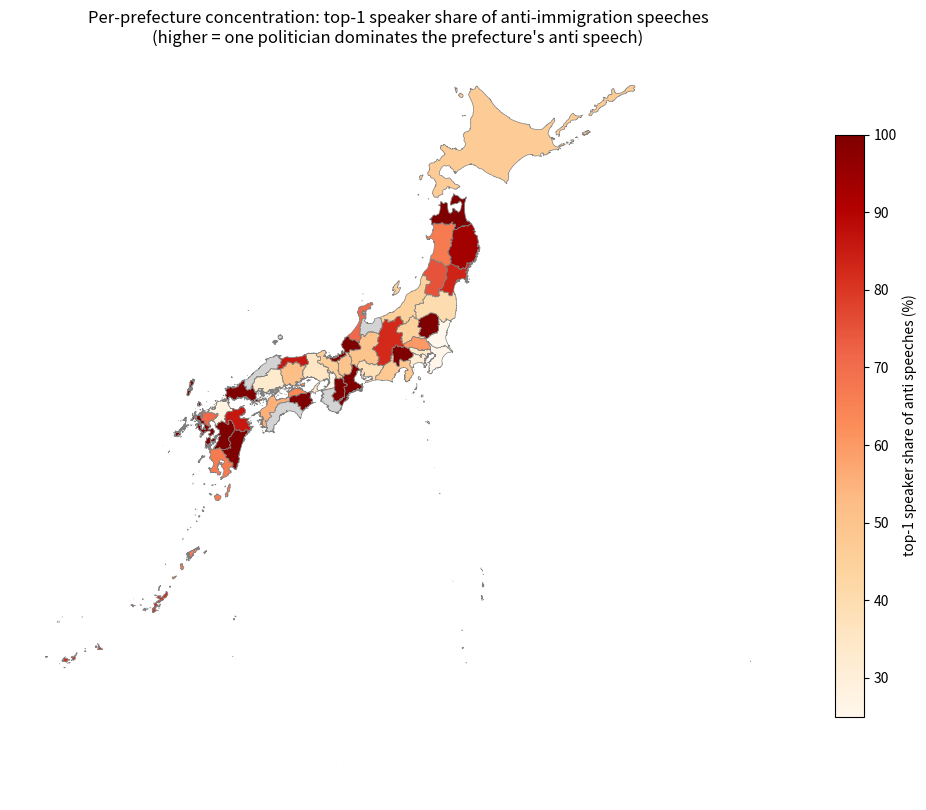

Top 10 prefectures by top-1 anti-share:
prefecture  n_anti  n_speakers  top1_pct  top3_pct
       三重県     1.0         1.0     100.0     100.0
       奈良県     1.0         1.0     100.0     100.0
       長崎県     1.0         1.0     100.0     100.0
       熊本県     1.0         1.0     100.0     100.0
       福井県     1.0         1.0     100.0     100.0
       青森県     1.0         1.0     100.0     100.0
       栃木県     1.0         1.0     100.0     100.0
       徳島県     1.0         1.0     100.0     100.0
       山梨県     2.0         1.0     100.0     100.0
       山口県    13.0         1.0     100.0     100.0


In [7]:
# Choropleth: per-prefecture top-1 speaker share of anti speeches
geojson_japan = "https://raw.githubusercontent.com/dataofjapan/land/master/japan.geojson"
japan_map = gpd.read_file(geojson_japan)
merged = japan_map.merge(pref_conc, left_on="nam_ja", right_on="prefecture", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(column="top1_pct", cmap="OrRd", legend=True, ax=ax,
            legend_kwds={"label": "top-1 speaker share of anti speeches (%)", "shrink": 0.6},
            edgecolor="grey", linewidth=0.5, missing_kwds={"color": "lightgrey"})
ax.set_title("Per-prefecture concentration: top-1 speaker share of anti-immigration speeches\n"
             "(higher = one politician dominates the prefecture's anti speech)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_choropleth_top1_share.png", bbox_inches="tight")
plt.show()

print("Top 10 prefectures by top-1 anti-share:")
print(pref_conc.sort_values("top1_pct", ascending=False).head(10).to_string(index=False))


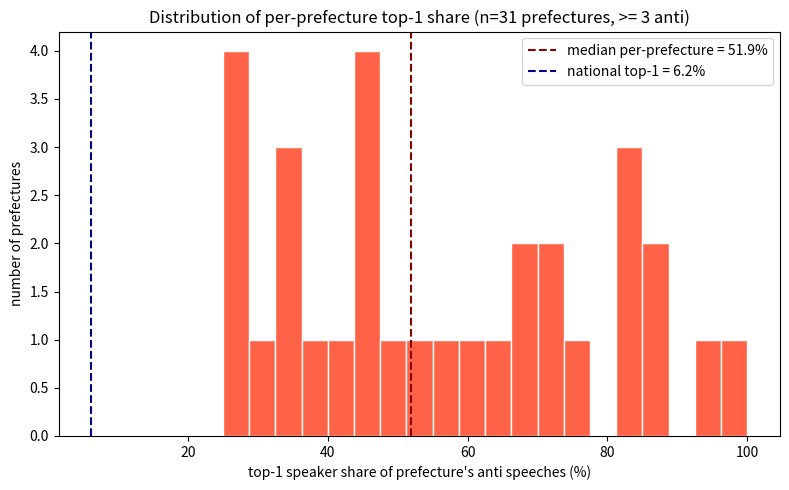

In [8]:
# Distribution of per-prefecture top-1 share (how concentrated are prefectures generally?)
nat_top1_local = counts.iloc[0] / counts.sum() * 100  # for vertical reference line
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pref_conc_filtered["top1_pct"], bins=20, color="tomato", edgecolor="white")
ax.axvline(pref_conc_filtered["top1_pct"].median(), color="darkred", linestyle="--",
           label=f"median per-prefecture = {pref_conc_filtered['top1_pct'].median():.1f}%")
ax.axvline(nat_top1_local, color="darkblue", linestyle="--",
           label=f"national top-1 = {nat_top1_local:.1f}%")
ax.set_xlabel("top-1 speaker share of prefecture's anti speeches (%)")
ax.set_ylabel("number of prefectures")
ax.set_title(f"Distribution of per-prefecture top-1 share (n={len(pref_conc_filtered)} prefectures, >= {MIN_N} anti)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_distribution_concentration.png", bbox_inches="tight")
plt.show()


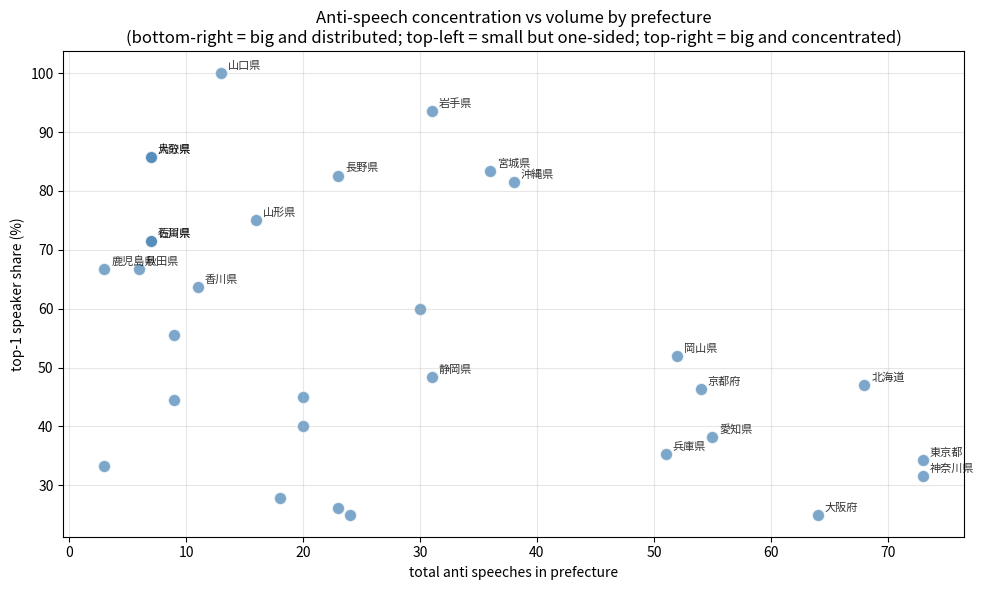

Spearman rho (n_anti vs top1_pct): -0.372, p = 0.0395
Interpretation: STRONG negative — larger prefectures less concentrated (expected, dilution)


In [9]:
# Does concentration correlate with speech volume? (small prefectures = high concentration by chance)
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(pref_conc_filtered["n_anti"], pref_conc_filtered["top1_pct"],
                s=80, c="steelblue", alpha=0.7, edgecolor="white")
for _, row in pref_conc_filtered.iterrows():
    if row["top1_pct"] > 60 or row["n_anti"] > 30:
        ax.annotate(row["prefecture"],
                    (row["n_anti"], row["top1_pct"]), fontsize=8, xytext=(5, 3),
                    textcoords="offset points", alpha=0.8)
ax.set_xlabel("total anti speeches in prefecture")
ax.set_ylabel("top-1 speaker share (%)")
ax.set_title("Anti-speech concentration vs volume by prefecture\n"
             "(bottom-right = big and distributed; top-left = small but one-sided; top-right = big and concentrated)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_concentration_vs_volume.png", bbox_inches="tight")
plt.show()

from scipy import stats
rho, pval = stats.spearmanr(pref_conc_filtered["n_anti"], pref_conc_filtered["top1_pct"])
print(f"Spearman rho (n_anti vs top1_pct): {rho:.3f}, p = {pval:.4f}")
if rho < -0.3:
    print("Interpretation: STRONG negative — larger prefectures less concentrated (expected, dilution)")
elif rho < -0.1:
    print("Interpretation: weak negative — small dilution effect")
else:
    print("Interpretation: no strong volume effect")


Concentration comparison:
                       level  top1_share_pct  top3_share_pct
     national (all speakers)            6.18           11.56
median prefecture (>=3 anti)           51.92           94.74
  mean prefecture (>=3 anti)           56.21           88.13


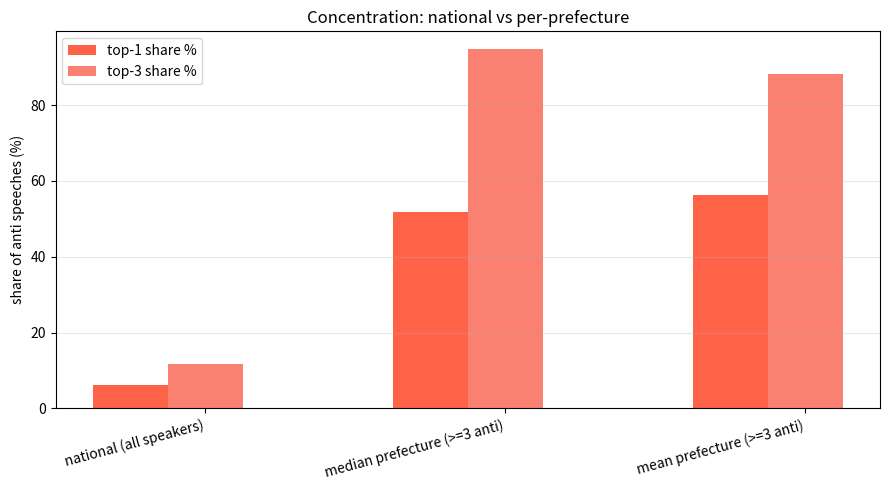


Key question: is anti speech concentrated nationally (a few big figures) or per prefecture (each has its own)?
  National top-1 share: 6.2%
  Median prefecture top-1 share: 51.9%
  -> Anti speech is MORE concentrated per prefecture (each region has its own champion)


In [10]:
# National vs per-prefecture: which level has more concentration?
summary = pd.DataFrame({
    "level": ["national (all speakers)", "median prefecture (>=3 anti)", "mean prefecture (>=3 anti)"],
    "top1_share_pct": [
        counts.iloc[0] / counts.sum() * 100,
        pref_conc_filtered["top1_pct"].median(),
        pref_conc_filtered["top1_pct"].mean(),
    ],
    "top3_share_pct": [
        counts.iloc[:3].sum() / counts.sum() * 100,
        pref_conc_filtered["top3_pct"].median(),
        pref_conc_filtered["top3_pct"].mean(),
    ],
})
print("Concentration comparison:")
print(summary.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary))
w = 0.25
ax.bar(x - w, summary["top1_share_pct"], w, label="top-1 share %", color="tomato")
ax.bar(x, summary["top3_share_pct"], w, label="top-3 share %", color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(summary["level"], rotation=15, ha="right")
ax.set_ylabel("share of anti speeches (%)")
ax.set_title("Concentration: national vs per-prefecture")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_national_vs_prefecture.png", bbox_inches="tight")
plt.show()

nat_top1 = counts.iloc[0] / counts.sum() * 100
med_pref_top1 = pref_conc_filtered["top1_pct"].median()
print(f"\nKey question: is anti speech concentrated nationally (a few big figures) or per prefecture (each has its own)?")
print(f"  National top-1 share: {nat_top1:.1f}%")
print(f"  Median prefecture top-1 share: {med_pref_top1:.1f}%")
if nat_top1 > med_pref_top1 + 10:
    print(f"  -> Anti speech is MORE concentrated nationally (top politicians dominate across Diet)")
elif med_pref_top1 > nat_top1 + 10:
    print(f"  -> Anti speech is MORE concentrated per prefecture (each region has its own champion)")
else:
    print(f"  -> Similar concentration at both levels")
